# Linear Regression

This notebook introduces linear regression, one of the oldest and most widely used methods in
machine learning and statistics. We will work through a real dataset one step at a time and look at
the main parts of the approach:

1. What linear regression is and when to use it
2. Loading and exploring the data
3. Fitting a line with one feature
4. Understanding the slope and intercept
5. How the "best" line is chosen
6. Measuring how good the model is
7. Checking the errors with a residual plot
8. Using more than one feature
9. Limitations to be aware of

The exercises at the end ask you to repeat these steps yourself with a different feature. Work
through the notebook in order and run each cell as you go (Shift + Enter).

## 1. What is linear regression?

**Regression** is a type of supervised learning where the thing we want to predict is a **number**,
for example a house price, a temperature, or an exam mark. This is different from classification,
where we predict a category such as "spam" or "not spam".

**Linear regression** makes its predictions by drawing a straight line through the data. With one
input feature, the line has the same form you may remember from school maths:

$$y = mx + c$$

- $y$ is the **label**: the number we want to predict.
- $x$ is the **feature**: the input we use to make the prediction.
- $m$ is the **slope**: how much $y$ changes when $x$ goes up by 1.
- $c$ is the **intercept**: the value of $y$ when $x$ is 0.

We supply $x$ and $y$ from our data. The job of the model is to find the values of $m$ and $c$ that
make the line fit the data as closely as possible. Because the model learns $m$ and $c$ from the
data, they are called the model's **parameters**.

## 2. Setting up

First we import the libraries we need. `pandas` holds the data in a table, `matplotlib` draws the
charts, and `scikit-learn` (imported as `sklearn`) provides the dataset, the model and the
performance measures.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

POINT_COLOUR = "#4A474F"
LINE_COLOUR = "#2a78d6"

## 3. The data

We will use the **diabetes dataset**, which comes with scikit-learn so there is nothing to
download. It contains measurements from 442 patients with diabetes, taken at the start of a study.
The label, `progression`, is a score that measures how far each patient's disease had progressed
one year later. A higher score means the disease got worse.

The original column names are short codes such as `bp` and `s5`, so we rename them to make them
easier to read.

In [2]:
data = load_diabetes(scaled=False, as_frame=True)
df = data.frame

df = df.rename(columns={
    "bp": "blood_pressure",
    "s1": "total_cholesterol",
    "s2": "ldl",
    "s3": "hdl",
    "s4": "chol_hdl_ratio",
    "s5": "log_triglycerides",
    "s6": "blood_sugar",
    "target": "progression",
})

print("Rows and columns:", df.shape)
df.head()

Rows and columns: (442, 11)


,age,sex,bmi,blood_pressure,total_cholesterol,ldl,hdl,chol_hdl_ratio,log_triglycerides,blood_sugar,progression
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0


Each row is one patient. The columns are:

| Column | Meaning |
|---|---|
| `age` | Age in years |
| `sex` | Recorded as 1 or 2 |
| `bmi` | Body mass index |
| `blood_pressure` | Average blood pressure |
| `total_cholesterol`, `ldl`, `hdl`, `chol_hdl_ratio` | Cholesterol measurements from a blood test |
| `log_triglycerides` | The log of the triglyceride level in the blood |
| `blood_sugar` | Blood sugar level |
| `progression` | **The label**: disease progression one year later |

`describe()` gives a quick summary of each column.

In [3]:
df.describe().round(2)

,age,sex,bmi,blood_pressure,total_cholesterol,ldl,hdl,chol_hdl_ratio,log_triglycerides,blood_sugar,progression
count,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00
mean,48.52,1.47,26.38,94.65,189.14,115.44,49.79,4.07,4.64,91.26,152.13
std,13.11,0.50,4.42,13.83,34.61,30.41,12.93,1.29,0.52,11.50,77.09
min,19.00,1.00,18.00,62.00,97.00,41.60,22.00,2.00,3.26,58.00,25.00
25%,38.25,1.00,23.20,84.00,164.25,96.05,40.25,3.00,4.28,83.25,87.00
50%,50.00,1.00,25.70,93.00,186.00,113.00,48.00,4.00,4.62,91.00,140.50
75%,59.00,2.00,29.28,105.00,209.75,134.50,57.75,5.00,5.00,98.00,211.50
max,79.00,2.00,42.20,133.00,301.00,242.40,99.00,9.09,6.11,124.00,346.00


The progression score ranges from 25 to 346, with an average of about 152. BMI ranges from 18 to
42. There are no missing values: every column has a count of 442.

Before building a model it is worth checking whether there is a relationship worth modelling. A
scatter plot of BMI against progression is a good start.

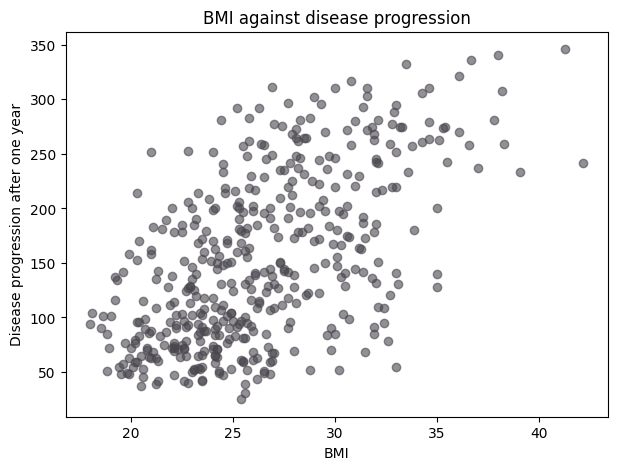

In [4]:
plt.figure(figsize=(7, 5))
plt.scatter(df["bmi"], df["progression"], color=POINT_COLOUR, alpha=0.6)
plt.xlabel("BMI")
plt.ylabel("Disease progression after one year")
plt.title("BMI against disease progression")
plt.show()

The points are spread out, but there is a clear upward trend: patients with a higher BMI tend to
have a higher progression score. The relationship looks roughly like a straight line, so linear
regression is a sensible thing to try.

We can put a number on the strength of the relationship with the **correlation**, which runs from
-1 (a perfect downward line) through 0 (no straight-line relationship) to +1 (a perfect upward
line).

In [5]:
df.corr()["progression"].sort_values(ascending=False).round(2)

progression          1.00
bmi                  0.59
log_triglycerides    0.57
blood_pressure       0.44
chol_hdl_ratio       0.43
blood_sugar          0.38
total_cholesterol    0.21
age                  0.19
ldl                  0.17
sex                  0.04
hdl                 -0.39
Name: progression, dtype: float64

BMI has the strongest correlation with progression (0.59), followed closely by
`log_triglycerides` (0.57). HDL is negatively correlated: higher HDL goes with lower progression.
We will start with BMI on its own.

## 4. Features, label and the train-test split

We separate the column we use to predict (the feature, `X`) from the column we want to predict (the
label, `y`). Note the **double square brackets** for `X`: scikit-learn expects the features as a
table, even when there is only one column.

We then split the patients into a **training set** (80%) that the model learns from and a **test
set** (20%) that we keep back to check how well the model works on patients it has never seen.
`random_state=42` makes the split the same every time the notebook is run.

In [6]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

X_train = train_df[["bmi"]]
y_train = train_df["progression"]
X_test = test_df[["bmi"]]
y_test = test_df["progression"]

print("Training patients:", len(train_df))
print("Test patients:", len(test_df))

Training patients: 353
Test patients: 89


## 5. Fitting the model

Fitting a linear regression model takes two lines: create the model, then call `fit` with the
training data. This is the step where the model learns its slope and intercept.

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope (m):     {slope:.2f}")
print(f"Intercept (c): {intercept:.2f}")

Slope (m):     10.76
Intercept (c): -131.87


After `fit`, the learned values are stored in `model.coef_` (the slope) and `model.intercept_` (the
intercept). The trailing underscore is a scikit-learn convention for "learned from the data".
`coef_` is a list with one value per feature, so we use `coef_[0]` to get the single slope.

So our model is:

$$\text{progression} = 10.76 \times \text{BMI} - 131.87$$

**Reading the slope.** For every extra point of BMI, the model predicts the progression score goes
up by about 10.8. This is the most useful number in the model, because it tells us how strongly the
label depends on the feature.

**Reading the intercept.** The intercept is the prediction when BMI is 0. That would give a
progression score of -131.87, which is impossible. This is not a mistake: nobody in the data has a
BMI anywhere near 0 (the lowest is 18), so the intercept simply positions the line in the right
place across the real data. It should not be read as a real prediction.

### Plotting the fitted line

Drawing the line over the training data shows what the model has learned.

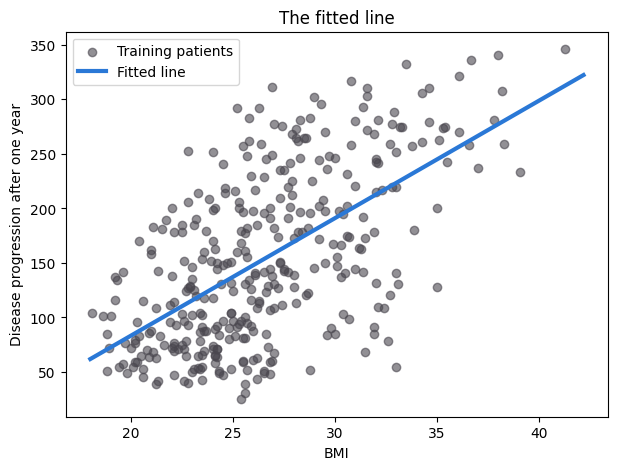

In [8]:
bmi_range = pd.DataFrame({"bmi": np.linspace(df["bmi"].min(), df["bmi"].max(), 100)})

plt.figure(figsize=(7, 5))
plt.scatter(X_train["bmi"], y_train, color=POINT_COLOUR, alpha=0.6, label="Training patients")
plt.plot(bmi_range["bmi"], model.predict(bmi_range), color=LINE_COLOUR, linewidth=3, label="Fitted line")
plt.xlabel("BMI")
plt.ylabel("Disease progression after one year")
plt.title("The fitted line")
plt.legend()
plt.show()

### Making a prediction

To predict for a new patient we pass their BMI to `predict`, again as a table with the same column
name used in training.

In [9]:
new_patient = pd.DataFrame({"bmi": [30]})
prediction = model.predict(new_patient)[0]
print(f"Predicted progression for BMI 30: {prediction:.1f}")

by_hand = slope * 30 + intercept
print(f"Worked out by hand:               {by_hand:.1f}")

Predicted progression for BMI 30: 191.0
Worked out by hand:               191.0


The two numbers are the same. For linear regression, `predict` does nothing more than
slope multiplied by the feature, plus the intercept. Once you know the two parameters you could
make predictions with a calculator.

## 6. How is the best line chosen?

Many lines could be drawn through the data, so how does `fit` decide which one is best?

For each patient, the difference between the real value and the line's prediction is called the
**residual** (or error):

$$\text{residual} = \text{actual} - \text{predicted}$$

A good line has small residuals. Linear regression uses the **least squares** method: it chooses the
slope and intercept that make the **sum of the squared residuals** as small as possible. Squaring
does two things: it stops positive and negative errors cancelling out, and it punishes large errors
more heavily than small ones.

The cell below shows the residuals for the first five training patients.

In [10]:
first_five = train_df[["bmi", "progression"]].head().copy()
first_five["predicted"] = model.predict(first_five[["bmi"]]).round(1)
first_five["residual"] = (first_five["progression"] - first_five["predicted"]).round(1)
first_five

,bmi,progression,predicted,residual
17,27.5,144.0,164.1,-20.1
66,24.7,150.0,134.0,16.0
137,31.0,280.0,201.8,78.2
245,23.1,125.0,116.7,8.3
31,20.3,59.0,86.6,-27.6


A positive residual means the patient's real score was higher than the model predicted; a negative
residual means it was lower.

To check that the fitted line really is the best, we can compare it with another line we choose
ourselves. We use the **mean squared error** (MSE), which is the average of the squared residuals.

In [11]:
fitted_predictions = model.predict(X_train)
fitted_mse = mean_squared_error(y_train, fitted_predictions)

# A line we have chosen by eye: slope 8, intercept -60
our_predictions = 8 * X_train["bmi"] - 60
our_mse = mean_squared_error(y_train, our_predictions)

print(f"MSE of the fitted line:     {fitted_mse:.0f}")
print(f"MSE of our own line:        {our_mse:.0f}")

MSE of the fitted line:     3854
MSE of our own line:        4003


Our hand-picked line has a larger error. Whatever slope and intercept you try, you will not beat the
fitted line on the training data, because least squares finds the values that give the smallest
possible MSE.

## 7. Measuring performance

The real test of a model is how well it predicts patients it has **not** seen, so we now use the
test set. There are three common measures for regression:

- **Mean Absolute Error (MAE)**: the average size of the errors, ignoring whether they are positive
  or negative. It is in the same units as the label, so it is easy to explain.
- **Root Mean Squared Error (RMSE)**: the square root of the MSE. It is also in the same units as
  the label, but because the errors are squared first, large errors count for more. RMSE is always
  at least as big as MAE.
- **R squared ($R^2$)**: the proportion of the variation in the label that the model explains. 1
  means perfect predictions; 0 means the model is no better than always predicting the average.

For MAE and RMSE, smaller is better. For $R^2$, bigger is better.

In [12]:
test_predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, test_predictions)
rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
r2 = r2_score(y_test, test_predictions)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.3f}")

MAE:  52.26
RMSE: 63.73
R2:   0.233


On average the predictions are about 52 points away from the real progression score. $R^2$ is 0.23,
which means BMI on its own explains about a quarter of the differences between patients. That is
useful but far from perfect, which is not surprising: disease progression depends on much more than
a single measurement.

**Is that any good?** A number on its own is hard to judge, so it helps to compare with a simple
**baseline**. The simplest possible "model" ignores the features and always predicts the average
progression score from the training set.

In [13]:
baseline_value = y_train.mean()
baseline_predictions = np.full(len(y_test), baseline_value)

print(f"Baseline always predicts: {baseline_value:.1f}")
print(f"Baseline MAE:  {mean_absolute_error(y_test, baseline_predictions):.2f}")
print(f"Baseline RMSE: {np.sqrt(mean_squared_error(y_test, baseline_predictions)):.2f}")

Baseline always predicts: 153.7
Baseline MAE:  64.01
Baseline RMSE: 73.22


The baseline's MAE is 64.0, compared with 52.3 for our model. Using BMI reduces the average error by
about 12 points, so the model has learned something real.

## 8. Checking the residuals

A **residual plot** shows the residual for each test patient against the model's prediction. If the
model is suitable, the points should be scattered randomly around the zero line with no obvious
pattern.

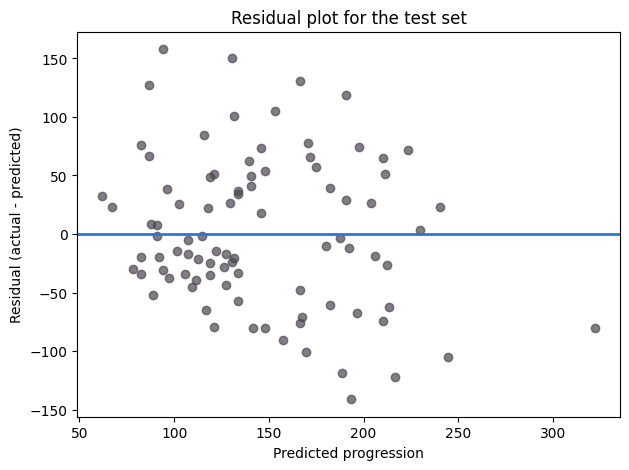

In [14]:
test_residuals = y_test - test_predictions

plt.figure(figsize=(7, 5))
plt.scatter(test_predictions, test_residuals, color=POINT_COLOUR, alpha=0.7)
plt.axhline(0, color=LINE_COLOUR, linewidth=2)
plt.xlabel("Predicted progression")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residual plot for the test set")
plt.show()

The residuals are spread above and below zero without a clear curve, which suggests a straight line
is a reasonable choice here. The spread is wide, which matches the fairly large MAE. Things to look
out for in a residual plot:

- **A curve** (for example, residuals positive at both ends and negative in the middle) means the
  real relationship is not a straight line.
- **A funnel shape** (residuals getting wider as the prediction grows) means the model is much less
  reliable for some patients than others.
- **A few points far from the rest** are outliers that may be pulling the line towards them.

## 9. Using more than one feature

Linear regression is not limited to one feature. With several features, the model learns **one
slope for each feature** plus a single intercept:

$$y = m_1 x_1 + m_2 x_2 + m_3 x_3 + c$$

This is called **multiple linear regression**. The code is exactly the same; we just select more
columns for `X`. Here we use BMI, blood pressure and log triglycerides.

In [15]:
features = ["bmi", "blood_pressure", "log_triglycerides"]

multi_model = LinearRegression()
multi_model.fit(train_df[features], y_train)

for name, coef in zip(features, multi_model.coef_):
    print(f"{name:<20} slope: {coef:.2f}")
print(f"{'intercept':<20}        {multi_model.intercept_:.2f}")

bmi                  slope: 7.01
blood_pressure       slope: 0.98
log_triglycerides    slope: 44.85
intercept                   -333.95


Each slope now means: the change in predicted progression when that feature goes up by 1, **with
the other features held the same**. For example, two patients with the same blood pressure and
triglycerides, but a BMI one point apart, would have predictions about 7.0 points apart.

Notice that the BMI slope has dropped from 10.76 to 7.01. Part of the effect that the one-feature
model gave to BMI is now shared with the other features, because they are related to each other.

**Be careful comparing slopes.** Each slope is in the units of its own feature. `log_triglycerides`
has the biggest slope (44.8), but it only varies between about 3.3 and 6.1, whereas blood pressure
varies between 62 and 133. A big slope does not automatically mean an important feature. If you
want to compare them fairly, scale the features first (for example with `StandardScaler`).

Now we compare the test performance with the one-feature model.

In [16]:
multi_predictions = multi_model.predict(test_df[features])

print(f"{'':<16}{'MAE':>8}{'RMSE':>8}{'R2':>8}")
print(f"{'BMI only':<16}{mae:>8.2f}{rmse:>8.2f}{r2:>8.3f}")
print(f"{'Three features':<16}"
      f"{mean_absolute_error(y_test, multi_predictions):>8.2f}"
      f"{np.sqrt(mean_squared_error(y_test, multi_predictions)):>8.2f}"
      f"{r2_score(y_test, multi_predictions):>8.3f}")

                     MAE    RMSE      R2
BMI only           52.26   63.73   0.233
Three features     44.29   53.77   0.454


Adding blood pressure and triglycerides improves every measure: the MAE drops from 52.3 to 44.3 and
$R^2$ nearly doubles, from 0.23 to 0.45. The extra features carry information that BMI alone does
not.

## 10. Limitations

Linear regression is simple, fast and easy to explain, which is why it is used so widely. It is
also a good first model to try on any regression problem. But it has limits:

- **It can only draw straight lines.** If the real relationship curves, a straight line will
  underfit. The residual plot helps you spot this.
- **Outliers pull the line.** Because errors are squared, a few extreme points can have a large
  effect on the slope.
- **Do not extrapolate.** The model only knows about the range of data it was trained on. A
  prediction for a BMI of 60, far above anything in the data, is a guess the model has no evidence
  for.
- **Correlation is not causation.** A positive slope for BMI shows that BMI and progression go
  together in this data. It does not prove that changing a patient's BMI would change their
  progression.

## 11. Summary

- Linear regression predicts a number by fitting a straight line: $y = mx + c$.
- `fit` learns the slope (`coef_`) and intercept (`intercept_`) using least squares, which makes
  the squared residuals as small as possible.
- The slope tells you how much the prediction changes when the feature goes up by 1.
- Evaluate on the test set with MAE, RMSE and $R^2$, and compare with a simple baseline.
- A residual plot is a quick check that a straight line is suitable.
- With several features, each feature gets its own slope.

---

# Exercises

These exercises repeat the main steps of the notebook with a different feature. The cells above must
have been run first, because the exercises use `train_df`, `test_df`, `model` and `multi_model`.

Write your code in the empty code cells, and write your answers to the questions in the text cells
(double-click a text cell to edit it).

### Exercise 1: A model using blood pressure

Build a linear regression model that predicts `progression` using **only** `blood_pressure`. Use
the same training data (`train_df`) as the notebook.

1. Create `X_train_bp` and `X_test_bp` using the `blood_pressure` column. Remember the double square
   brackets.
2. Create a `LinearRegression` model called `bp_model` and fit it on the training data.
3. Print the slope and the intercept.

In [17]:
# Your code here

**Question:** In one sentence, explain what the slope means in terms of blood pressure and
progression.

*Your answer:*

### Exercise 2: Making a prediction

1. Use `bp_model` to predict the progression score for a patient with a blood pressure of 100.
2. Check your answer by working it out by hand, using the slope and intercept from Exercise 1.

In [18]:
# Your code here

### Exercise 3: Plotting the line

Make a scatter plot of the **test** patients, with blood pressure on the x-axis and progression on
the y-axis. Draw the fitted line from `bp_model` on top. Give the chart axis labels and a title.

Hint: look back at the plot in Section 5.

In [19]:
# Your code here

### Exercise 4: Evaluating the model

Calculate the MAE, RMSE and $R^2$ of `bp_model` on the test set.

In [20]:
# Your code here

**Question:** Compare your results with the BMI model from Section 7 (MAE 52.26, $R^2$ 0.233).
Which feature is more useful for predicting progression on its own? Does this match what the
correlations in Section 3 suggested?

*Your answer:*

### Exercise 5: Calculating MAE yourself

Calculate the MAE of `bp_model` on the test set **without** using `mean_absolute_error`. Use NumPy:
find the difference between the actual and predicted values, take the absolute value
(`np.abs`), then take the mean. Check that you get the same answer as in Exercise 4.

In [21]:
# Your code here

### Exercise 6: Using all of the features

Build a model called `all_model` that uses **all ten** features (every column except
`progression`). Calculate its MAE and $R^2$ on the test set.

Hint: `train_df.drop(columns="progression")` gives you every column except the label.

In [22]:
# Your code here

**Question:** Compare the result with the three-feature model in Section 9 (MAE 44.29,
$R^2$ 0.454). Did adding the other seven features help? Why do you think that might be?

*Your answer:*

### Exercise 7: Extrapolation

Use the BMI model from Section 5 (`model`) to predict the progression score for a patient with a
BMI of 60.

In [23]:
# Your code here

**Question:** Look at the largest BMI and the largest progression score in the data
(`df.describe()` in Section 3). Should we trust this prediction? Explain why.

*Your answer:*

### Exercise 8 (challenge): How much does the split matter?

The test set only has 89 patients, so the results depend on which patients happen to end up in it.

Write a loop that repeats the BMI model for `random_state` values 0, 1, 2, 3 and 4. For each one,
split the data again, fit a new model on the training part and print the test $R^2$.

In [24]:
# Your code here

**Question:** How much does $R^2$ change between splits? What does this tell you about trusting a
single test score, and what technique could give a more reliable estimate?

*Your answer:*